# Aula Completa: Exploratory Data Analysis (EDA)

Este notebook explica **passo a passo** o processo de **Exploratory Data Analysis (EDA)** usado em projetos de Machine Learning e Data Science.

A ideia da EDA é:

1. Entender o dataset
2. Identificar problemas nos dados
3. Descobrir padrões
4. Preparar os dados para modelagem

Cada bloco de código possui uma explicação antes dele.


## 1. Importar bibliotecas

Antes de começar qualquer análise precisamos importar as bibliotecas principais de Data Science.

Usaremos:

- **pandas** → manipulação de dados
- **numpy** → operações matemáticas
- **matplotlib / seaborn** → visualização de dados


In [1]:
# ==============================
# Imports
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data.load_data import load_dataset
from src.data.preprocess import create_target

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

np.random.seed(42)


## 2. Carregar o Dataset

Aqui carregamos o dataset usando **pandas**.

Normalmente os datasets estão em formato:

- CSV
- Excel
- Parquet


In [2]:
df = load_dataset("../data/raw/bmw_global_sales_2018_2025.csv")

print("Cabeçalho: ")

df.head()

Cabeçalho: 


,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


## 3. Entender a estrutura do dataset

Antes de qualquer análise precisamos entender:

- Quantas linhas existem
- Quantas colunas existem
- Tipos de dados


In [3]:
print("Volume: ", df.shape)

Volume:  (3072, 11)


In [4]:
print("\nInformações dos tipos de dados do dataset:\n")

df.info()


Informações dos tipos de dados do dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


## 4. Estatísticas básicas

Agora analisamos estatísticas importantes das colunas numéricas:

- média
- desvio padrão
- mínimo
- máximo
- quartis

Isso ajuda a identificar **outliers e distribuições estranhas**.


In [5]:
df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


## 5. Verificar valores faltantes (Missing Values)

Datasets reais quase sempre possuem valores faltantes.

Precisamos descobrir:

- quais colunas têm valores faltantes
- quantos existem


In [6]:
df.isnull().sum().sort_values(ascending=False)

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

## 6. Distribuição das variáveis

Agora analisamos **como os dados estão distribuídos**.

Isso ajuda a entender:

- normalidade
- presença de outliers
- concentração de valores


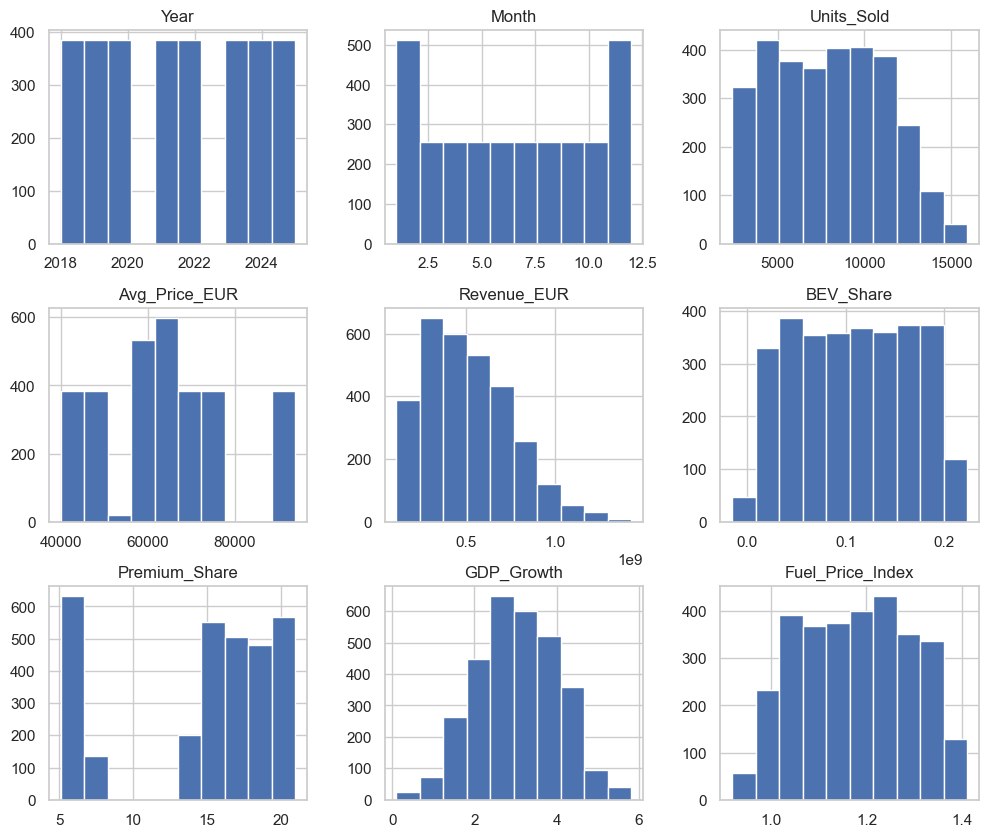

In [7]:
df.hist(figsize=(12,10))
plt.show()

## 7. Análise de correlação

A correlação mostra **quais variáveis estão relacionadas**.

Valores próximos de:

- **1** → forte correlação positiva
- **-1** → forte correlação negativa
- **0** → pouca relação


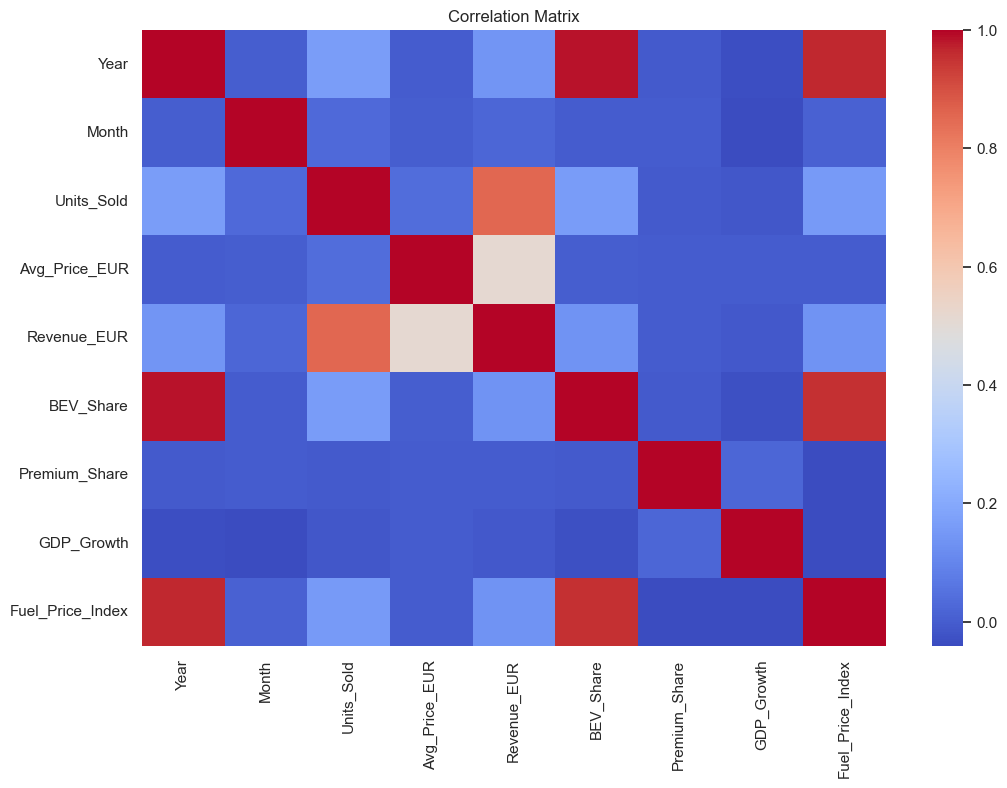

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 8. Visualizações importantes

Alguns gráficos ajudam muito na EDA:

- **Boxplot** → detectar outliers
- **Countplot** → frequência de categorias
- **Scatterplot** → relação entre variáveis


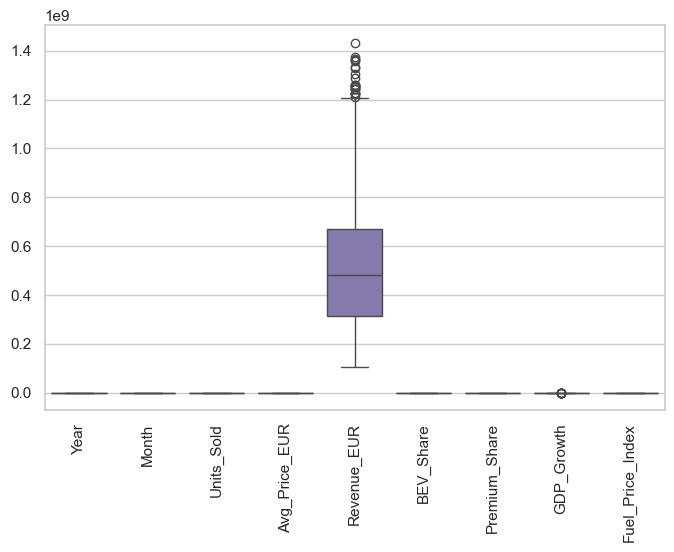

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

## 9. Separar dados de treino e teste

Uma etapa comum antes de treinar modelos é separar os dados.

Aqui usamos **train_test_split**.


In [10]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (2457, 11)
Test shape: (615, 11)


## 10. Salvar o dataset de teste

Por fim salvamos o dataset de teste para uso posterior.


In [12]:
df.to_csv("../data/processed/ev_adoption_processed.csv", index=False)

# Conclusão

Neste notebook fizemos:

1. Carregamento de dados
2. Inspeção da estrutura
3. Estatísticas descritivas
4. Identificação de valores faltantes
5. Visualização de distribuições
6. Análise de correlação
7. Criação de gráficos
8. Separação treino/teste
9. Salvamento do dataset

Este fluxo é **o padrão em praticamente todo projeto de Data Science**.
